# Public ChEMBL Evidence Audit for a HADHA–ENO1 Madecassic Acid Hypothesis

This notebook evaluates whether publicly available ChEMBL records associated with HADHA and ENO1 provide sufficient and interpretable evidence for target-specific ligand-based inference.

This is a data-provenance and feasibility audit. It does not establish direct binding, enzyme inhibition, selectivity, cellular target engagement, or an anticancer mechanism for madecassic acid or any analogue.

**Decision criterion:** a target-specific ligand model will not be attempted unless the retained structures are sufficiently numerous, chemically diverse, assay-context compatible, and suitable for explicit validation.

## Research question

An earlier structure-based study generated the hypothesis that HADHA may provide a more favourable binding environment than ENO1 for madecassic-acid-like compounds.

This notebook asks a narrower question:

> Are the public ChEMBL records associated with HADHA and ENO1 sufficiently defined and chemically diverse to justify target-specific ligand-based modelling?

The analysis proceeds in stages:

1. Data provenance and target-identity checks  
2. Assay-context audit  
3. SMILES validation and structure curation  
4. Record-to-structure provenance and multi-component audit  
5. Structure-level diversity and chemical-space assessment  
6. Explicit feasibility decision  
7. Interpretation and pre-specified orthogonal validation planning

## Biological context

HADHA and ENO1 were selected because they were biologically relevant proteins in the broader hepatocellular carcinoma context. [1]

Earlier structure-based work generated the hypothesis that HADHA may provide a more favourable binding environment than ENO1 for madecassic-acid-like compounds. This notebook does not evaluate receptor structures, biological assemblies, binding pockets, docking poses, docking scores, or binding free energies.

Instead, it evaluates whether public ligand-associated records provide an independent and sufficiently robust basis for ligand-based inference. Madecassic acid is used only as a defined chemical reference for descriptive two-dimensional similarity analysis.

In [1]:
from pathlib import Path
from hashlib import sha256
from datetime import datetime, timezone
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import rdkit
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

In [2]:
RADIUS = 2
NBITS = 2048

TARGET_ORDER = [
    "HADHA",
    "ENO1",
]

OUTPUT_DIR = Path("../results")
FIGURES_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

MORGAN_GENERATOR = AllChem.GetMorganGenerator(
    radius=RADIUS,
    fpSize=NBITS,
    countSimulation=False
)

print("Python:", sys.version.split()[0])
print("RDKit:", rdkit.__version__)
print(
    f"Fingerprint: Morgan radius={RADIUS}, "
    f"nBits={NBITS}"
)
print(
    "Run time (UTC):",
    datetime.now(timezone.utc).isoformat()
)
print("Results directory:", OUTPUT_DIR.resolve())

Python: 3.13.9
RDKit: 2026.03.3
Fingerprint: Morgan radius=2, nBits=2048
Run time (UTC): 2026-07-14T10:46:37.590439+00:00
Results directory: /Users/sk/Desktop/HADHA-ENO1-public-ligand-analysis-main/results


## Data provenance

The input files are retained as raw ChEMBL exports. File-level SHA-256 checksums are recorded because ChEMBL content and export formatting can change over time. [2]

No activity labels are created in this notebook. The records are not harmonised across assay types, endpoints, units, relation operators, document sources, or experimental contexts.

Therefore, activity values are not used to rank potency, estimate affinity, define active/inactive classes, or train predictive models.

In [3]:
EXPECTED_TARGET_IDS = {
    "HADHA": "CHEMBL4295759",
    "ENO1": "CHEMBL3298",
}

CH_EMBL_EXPORT_DATE = "2026-06-23"

DATA_DIR = Path("../data")

FILE_PATHS = {
    "HADHA": DATA_DIR / "HADHA_bioactivity_data.csv",
    "ENO1": DATA_DIR / "ENO1_bioactivity_data.csv",
}

missing_files = [
    str(path.resolve())
    for path in FILE_PATHS.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required input files were not found:\n"
        + "\n".join(missing_files)
    )

print("Using data directory:")
print(DATA_DIR.resolve())

print("\nInput files found:")
for target, path in FILE_PATHS.items():
    print(f"{target}: {path.name}")

Using data directory:
/Users/sk/Desktop/HADHA-ENO1-public-ligand-analysis-main/data

Input files found:
HADHA: HADHA_bioactivity_data.csv
ENO1: ENO1_bioactivity_data.csv


In [4]:
def file_sha256(path):
    return sha256(path.read_bytes()).hexdigest()


raw_data = {
    target: pd.read_csv(path, sep=";")
    for target, path in FILE_PATHS.items()
}

provenance = pd.DataFrame(
    [
        {
            "Target": target,
            "Input file": path.name,
            "Export date": CH_EMBL_EXPORT_DATE,
            "Downloaded records": len(raw_data[target]),
            "SHA256": file_sha256(path),
        }
        for target, path in FILE_PATHS.items()
    ]
)

display(provenance)

,Target,Input file,Export date,Downloaded records,SHA256
0,HADHA,HADHA_bioactivity_data.csv,2026-06-23,7,1c29e8f5d7ff4d216348046272d5570e73297156a0396e...
1,ENO1,ENO1_bioactivity_data.csv,2026-06-23,39,68cfabf81d90ae2d390851953894b0378bf5b8a93e28fb...


## Target identity check

The ChEMBL target identifier is checked before analysis to ensure that the correct target has been selected and that records from different targets have not been combined. The available target metadata are then reviewed and recorded to confirm the target name and target type.



In [5]:
for target in TARGET_ORDER:
    if "Target ChEMBL ID" not in raw_data[target].columns:
        raise KeyError(
            f"{target}: missing 'Target ChEMBL ID' column."
        )

    observed_ids = set(
        raw_data[target]["Target ChEMBL ID"]
        .dropna()
        .astype(str)
        .unique()
    )

    if observed_ids != {EXPECTED_TARGET_IDS[target]}:
        raise ValueError(
            f"{target}: expected {EXPECTED_TARGET_IDS[target]}, "
            f"but found {sorted(observed_ids)}."
        )

print("Target ChEMBL ID checks passed.")

Target ChEMBL ID checks passed.


In [6]:
TARGET_METADATA_COLUMNS = [
    "Target ChEMBL ID",
    "Target Name",
    "Target Type",
    "Organism",
    "Target Confidence Score",
]

for target in TARGET_ORDER:
    available_columns = [
        column
        for column in TARGET_METADATA_COLUMNS
        if column in raw_data[target].columns
    ]

    print(f"\n{target}: available target metadata")

    display(
        raw_data[target][available_columns]
        .fillna("Missing")
        .drop_duplicates()
        .reset_index(drop=True)
    )


HADHA: available target metadata


,Target ChEMBL ID,Target Name,Target Type
0,CHEMBL4295759,"Trifunctional enzyme subunit alpha, mitochondrial",SINGLE PROTEIN



ENO1: available target metadata


,Target ChEMBL ID,Target Name,Target Type
0,CHEMBL3298,Alpha-enolase,SINGLE PROTEIN


## Assay-context audit

The table below summarises the assay and measurement information for the extracted records. It highlights the internal variation in the dataset. It should not be read as a basis for direct comparison across all records.

Differences in assay format, endpoint, units, relation operators, source documents, and experimental methods mean that the activity values should not be regarded as a single harmonised, target-specific dataset.

In [7]:
ASSAY_COLUMNS = [
    "Assay ChEMBL ID",
    "Assay Type",
    "Target Name",
    "Target Type",
    "Standard Type",
    "Standard Relation",
    "Standard Units",
    "Document ChEMBL ID",
]

for target in TARGET_ORDER:
    available_columns = [
        column
        for column in ASSAY_COLUMNS
        if column in raw_data[target].columns
    ]

    assay_audit = (
        raw_data[target][available_columns]
        .fillna("Missing")
        .value_counts()
        .reset_index(name="Record count")
        .sort_values(
            "Record count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print(f"\n{target}: assay and measurement context")
    display(assay_audit)


HADHA: assay and measurement context


,Assay ChEMBL ID,Assay Type,Target Name,Target Type,Standard Type,Standard Relation,Standard Units,Document ChEMBL ID,Record count
0,CHEMBL5651524,B,"Trifunctional enzyme subunit alpha, mitochondrial",SINGLE PROTEIN,ED50,'=',nM,CHEMBL5649169,2
1,CHEMBL5651524,B,"Trifunctional enzyme subunit alpha, mitochondrial",SINGLE PROTEIN,Kd,'=',nM,CHEMBL5649169,2
2,CHEMBL4118666,B,"Trifunctional enzyme subunit alpha, mitochondrial",SINGLE PROTEIN,Activity,Missing,Missing,CHEMBL4118021,1
3,CHEMBL4118852,B,"Trifunctional enzyme subunit alpha, mitochondrial",SINGLE PROTEIN,Activity,Missing,Missing,CHEMBL4118021,1
4,CHEMBL5036295,B,"Trifunctional enzyme subunit alpha, mitochondrial",SINGLE PROTEIN,Activity,Missing,Missing,CHEMBL5034051,1



ENO1: assay and measurement context


,Assay ChEMBL ID,Assay Type,Target Name,Target Type,Standard Type,Standard Relation,Standard Units,Document ChEMBL ID,Record count
0,CHEMBL5107357,B,Alpha-enolase,SINGLE PROTEIN,IC50,'=',nM,CHEMBL5104201,5
1,CHEMBL4621995,B,Alpha-enolase,SINGLE PROTEIN,IC50,'=',nM,CHEMBL4619798,3
2,CHEMBL4621996,B,Alpha-enolase,SINGLE PROTEIN,IC50,'=',nM,CHEMBL4619798,3
3,CHEMBL4621998,B,Alpha-enolase,SINGLE PROTEIN,IC50,'=',nM,CHEMBL4619798,3
4,CHEMBL4621999,B,Alpha-enolase,SINGLE PROTEIN,IC50,'=',nM,CHEMBL4619798,3
5,CHEMBL5651363,B,Alpha-enolase,SINGLE PROTEIN,Kd,'=',nM,CHEMBL5649169,2
6,CHEMBL4621992,B,Alpha-enolase,SINGLE PROTEIN,IC50,'=',nM,CHEMBL4619798,2
7,CHEMBL4621993,B,Alpha-enolase,SINGLE PROTEIN,IC50,'=',nM,CHEMBL4619798,2
8,CHEMBL5382470,B,Alpha-enolase,SINGLE PROTEIN,Activity,Missing,Missing,CHEMBL5380806,2
9,CHEMBL5651363,B,Alpha-enolase,SINGLE PROTEIN,ED50,'=',nM,CHEMBL5649169,2


## Computational implementation

SMILES parsing, parent-fragment standardisation, descriptor calculation, Morgan fingerprint generation, Tanimoto similarity calculation, and Murcko scaffold extraction were performed with RDKit. [3]

Morgan fingerprints were generated with radius 2 and 2,048 bits. [4] Murcko scaffolds were used to describe the overall diversity of structural frameworks in the dataset, rather than to define formal series of compounds with related activity. [5]

## Structure curation

Records with missing or invalid SMILES are excluded from chemical-structure analysis.

For multi-component SMILES, the largest organic fragment was retained for structural analysis. This approach reduces the influence of salts, counterions, and other disconnected components on descriptors and fingerprint-based similarity measures.

This standardisation was applied to allow consistent structural comparisons and does not imply that the retained parent fragment precisely represents the chemical form tested in the assay.

In [8]:
def mol_from_smiles(smiles):
    if pd.isna(smiles):
        return None

    return Chem.MolFromSmiles(str(smiles))


def is_multicomponent(smiles):
    return "." in str(smiles)


def largest_organic_fragment(mol):
    fragments = Chem.GetMolFrags(
        mol,
        asMols=True,
        sanitizeFrags=True
    )

    organic_fragments = [
        fragment
        for fragment in fragments
        if any(
            atom.GetAtomicNum() > 1
            for atom in fragment.GetAtoms()
        )
    ]

    if not organic_fragments:
        return None

    return max(
        organic_fragments,
        key=lambda fragment: fragment.GetNumHeavyAtoms()
    )


def calculate_descriptors(mol):
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
    }


def scaffold_smiles(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)

    if scaffold.GetNumAtoms() == 0:
        return "acyclic"

    return Chem.MolToSmiles(
        scaffold,
        isomericSmiles=True
    )


def fingerprint(mol):
    return MORGAN_GENERATOR.GetFingerprint(mol)

In [9]:
def curate_records(df, target):
    if "Smiles" not in df.columns:
        raise KeyError(
            f"{target}: missing 'Smiles' column."
        )

    out = df.copy()
    out["Target"] = target

    out["Mol_raw"] = out["Smiles"].apply(
        mol_from_smiles
    )

    out["Valid_SMILES"] = out["Mol_raw"].notna()

    out = out.loc[
        out["Valid_SMILES"]
    ].copy()

    out["Multi_component"] = out["Smiles"].apply(
        is_multicomponent
    )

    out["Mol_parent"] = out["Mol_raw"].apply(
        largest_organic_fragment
    )

    out = out.dropna(
        subset=["Mol_parent"]
    ).copy()

    out["Canonical_SMILES_stereo"] = out[
        "Mol_parent"
    ].apply(
        lambda mol: Chem.MolToSmiles(
            mol,
            isomericSmiles=True
        )
    )

    out["Canonical_SMILES_no_stereo"] = out[
        "Mol_parent"
    ].apply(
        lambda mol: Chem.MolToSmiles(
            mol,
            isomericSmiles=False
        )
    )

    return out.reset_index(drop=True)


curated = {
    target: curate_records(
        raw_data[target],
        target
    )
    for target in TARGET_ORDER
}

In [10]:
curation_audit = pd.DataFrame(
    [
        {
            "Target": target,
            "Downloaded records": len(raw_data[target]),
            "Valid SMILES records": len(curated[target]),
            "Multi-component records": int(
                curated[target]["Multi_component"].sum()
            ),
            "Retained parent-fragment records": len(
                curated[target]
            ),
        }
        for target in TARGET_ORDER
    ]
)

display(curation_audit)

,Target,Downloaded records,Valid SMILES records,Multi-component records,Retained parent-fragment records
0,HADHA,7,7,0,7
1,ENO1,39,39,1,39


### Record-to-structure provenance

Before duplicate structures were consolidated, the table below summarises the number of public ChEMBL records, assays, and source documents associated with each retained canonical parent structure, while preserving stereochemical information.

This provides an audit trail showing whether multiple public records relate to the same chemical structure or to distinct structures. It is intended only to record data provenance; repeated records should not be interpreted as independent experimental replicates or as directly comparable activity measurements.

In [11]:
duplicate_provenance = pd.concat(
    [
        curated[target]
        .groupby(
            [
                "Target",
                "Canonical_SMILES_stereo",
            ],
            dropna=False
        )
        .agg(
            Public_records=(
                "Molecule ChEMBL ID",
                "size"
            ),
            Molecule_chembl_ids=(
                "Molecule ChEMBL ID",
                lambda values: "; ".join(
                    sorted(
                        set(
                            values.dropna().astype(str)
                        )
                    )
                )
            ),
            Assays=(
                "Assay ChEMBL ID",
                lambda values: values.nunique()
            ),
            Documents=(
                "Document ChEMBL ID",
                lambda values: values.nunique()
            ),
        )
        .reset_index()
        .sort_values(
            [
                "Target",
                "Public_records",
            ],
            ascending=[
                True,
                False,
            ]
        )
        .reset_index(drop=True)
        for target in TARGET_ORDER
    ],
    ignore_index=True
)

display(
    duplicate_provenance[
        [
            "Target",
            "Public_records",
            "Molecule_chembl_ids",
            "Assays",
            "Documents",
        ]
    ]
)

,Target,Public_records,Molecule_chembl_ids,Assays,Documents
0,HADHA,2,CHEMBL4129274,2,1
1,HADHA,2,CHEMBL3752910,1,1
2,HADHA,2,CHEMBL5653589,1,1
3,HADHA,1,CHEMBL5094288,1,1
4,ENO1,6,CHEMBL4647008,6,1
5,ENO1,6,CHEMBL1232461,6,1
6,ENO1,4,CHEMBL4643988,4,1
7,ENO1,4,CHEMBL260046,4,1
8,ENO1,3,CHEMBL4647387,3,2
9,ENO1,2,CHEMBL4633981,2,1


### Multi-component record audit

For multi-component SMILES, both the original exported structure and the largest organic fragment retained for analysis are reported. This allows the standardisation process to be checked, while recognising that the retained parent fragment may not fully reflect the chemical entity used in the assay.

In [12]:
multicomponent_audit = pd.concat(
    [
        curated[target]
        .loc[
            curated[target]["Multi_component"],
            [
                "Target",
                "Molecule ChEMBL ID",
                "Smiles",
                "Canonical_SMILES_stereo",
            ],
        ]
        for target in TARGET_ORDER
    ],
    ignore_index=True
)

display(multicomponent_audit)

,Target,Molecule ChEMBL ID,Smiles,Canonical_SMILES_stereo
0,ENO1,CHEMBL5411524,C#CCOc1ccc(-c2c(C)c2=[N+](CC)CC)cc1.F[B-](F)(F)F,C#CCOc1ccc(-c2c(C)c2=[N+](CC)CC)cc1


## Structure-level audit

A ChEMBL record count does not equal the number of independent chemical structures because the same compound can occur in multiple assays or documents.

Structures are deduplicated separately within each target using stereo-preserving canonical SMILES. Stereo-agnostic counts are also reported as a conservative measure of broad two-dimensional structural diversity.

In [13]:
def unique_structure_table(df, target):
    unique = (
        df.sort_values("Multi_component")
        .drop_duplicates(
            subset="Canonical_SMILES_stereo"
        )
        .copy()
        .reset_index(drop=True)
    )

    unique["Scaffold"] = unique[
        "Mol_parent"
    ].apply(scaffold_smiles)

    descriptor_df = pd.DataFrame(
        unique["Mol_parent"]
        .apply(calculate_descriptors)
        .tolist()
    )

    unique = pd.concat(
        [
            unique,
            descriptor_df,
        ],
        axis=1
    )

    unique["Fingerprint"] = unique[
        "Mol_parent"
    ].apply(fingerprint)

    unique["Target"] = target

    return unique


structures = {
    target: unique_structure_table(
        curated[target],
        target
    )
    for target in TARGET_ORDER
}

In [14]:
structure_audit = pd.DataFrame(
    [
        {
            "Target": target,
            "Curated records": len(curated[target]),
            "Unique stereo-preserving structures": (
                structures[target][
                    "Canonical_SMILES_stereo"
                ].nunique()
            ),
            "Unique stereo-agnostic structures": (
                structures[target][
                    "Canonical_SMILES_no_stereo"
                ].nunique()
            ),
            "Unique Murcko scaffolds": (
                structures[target][
                    "Scaffold"
                ].nunique()
            ),
        }
        for target in TARGET_ORDER
    ]
)

display(structure_audit)

,Target,Curated records,Unique stereo-preserving structures,Unique stereo-agnostic structures,Unique Murcko scaffolds
0,HADHA,7,4,4,4
1,ENO1,39,18,18,15


## Feasibility decision

A target-specific ligand model is not meaningful unless there are enough chemically distinct compounds and a validation strategy that can actually test the result.

The limited number of publicly available HADHA data points reflects gaps in public data availability and assay coverage. It should not be interpreted as evidence that madecassic acid does not bind to HADHA.

Although the ENO1 dataset contains more unique structures than the HADHA dataset, it is not suitable for direct modelling in its current form. The records include different endpoint types, assay conditions, and measurement definitions. Consequently, the data cannot support development of a quantitative ENO1 potency model, a binary activity classifier, or a model comparing preference between HADHA and ENO1.

In [15]:
HADHA_N_STRUCTURES = (
    structures["HADHA"][
        "Canonical_SMILES_no_stereo"
    ].nunique()
)

HADHA_N_SCAFFOLDS = (
    structures["HADHA"][
        "Scaffold"
    ].nunique()
)

if HADHA_N_STRUCTURES < 10:
    decision = (
        "Do not train a HADHA-specific ligand model. "
        "With fewer than 10 unique structures, neither a meaningful "
        "train/test split nor an internal validation strategy is feasible."
    )
else:
    decision = (
        "Dataset size does not by itself preclude exploratory analysis. "
        "Assay harmonisation, label definition, analogue-series analysis, "
        "and validation design would still be required before modelling."
    )

print(
    "HADHA unique stereo-agnostic structures:",
    HADHA_N_STRUCTURES
)

print(
    "HADHA unique Murcko scaffolds:",
    HADHA_N_SCAFFOLDS
)

print("\nDecision:", decision)

HADHA unique stereo-agnostic structures: 4
HADHA unique Murcko scaffolds: 4

Decision: Do not train a HADHA-specific ligand model. With fewer than 10 unique structures, neither a meaningful train/test split nor an internal validation strategy is feasible.


## Descriptive chemical-space assessment

The retained structures are compared using molecular weight, calculated LogP, topological polar surface area, and fraction of sp3 carbons.

These plots provide descriptive chemical context only. They do not estimate affinity, potency, target preference, selectivity, ligandability, or therapeutic relevance.

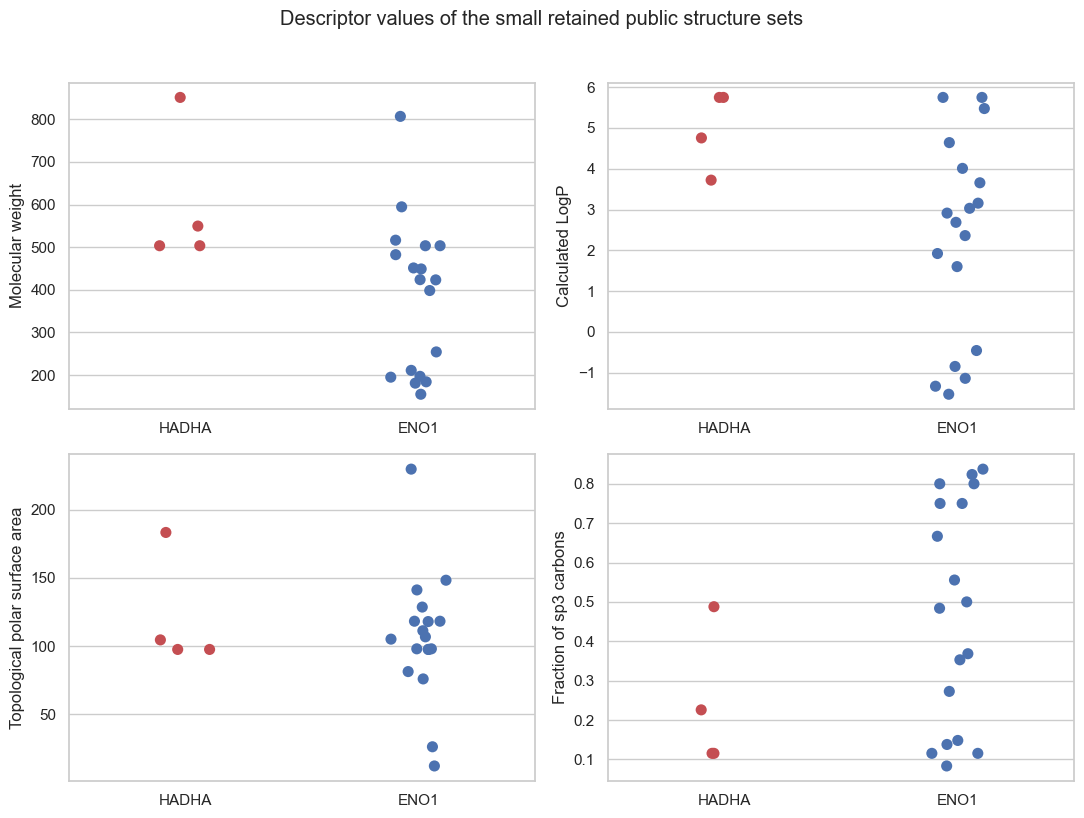

In [16]:
DESCRIPTOR_COLUMNS = [
    "MolWt",
    "LogP",
    "TPSA",
    "FractionCSP3",
]

DESCRIPTOR_LABELS = {
    "MolWt": "Molecular weight",
    "LogP": "Calculated LogP",
    "TPSA": "Topological polar surface area",
    "FractionCSP3": "Fraction of sp3 carbons",
}

plot_data = pd.concat(
    [
        structures[target][
            [
                "Target",
                *DESCRIPTOR_COLUMNS,
            ]
        ]
        for target in TARGET_ORDER
    ],
    ignore_index=True
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(11, 8)
)

for ax, descriptor in zip(
    axes.flat,
    DESCRIPTOR_COLUMNS
):
    sns.stripplot(
        data=plot_data,
        x="Target",
        y=descriptor,
        order=TARGET_ORDER,
        hue="Target",
        palette={
            "HADHA": "#C44E52",
            "ENO1": "#4C72B0",
        },
        jitter=0.12,
        size=8,
        legend=False,
        ax=ax
    )

    ax.set_xlabel("")
    ax.set_ylabel(DESCRIPTOR_LABELS[descriptor])

fig.suptitle(
    "Descriptor values of the small retained public structure sets",
    y=1.02
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "descriptor_context.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Madecassic-acid similarity context

Madecassic acid is used as a predefined chemical reference. Madecassic acid was represented using the PubChem CID 73412 structure record, accessed on 2026-07-13. [6]

Morgan fingerprint similarity represents broad two-dimensional structural resemblance. It does not demonstrate direct binding, a shared binding mode, potency, target selectivity, or biological activity.

In [17]:
MADECASSIC_ACID_SMILES = (
    "C[C@@H]1CC[C@@]2(CC[C@@]3(C(=CC[C@H]4[C@]3(C[C@H]([C@@H]5[C@@]4(C[C@H]([C@@H]([C@@]5(C)CO)O)O)C)O)C)[C@@H]2[C@H]1C)C)C(=O)O"
)

madecassic_acid_mol = Chem.MolFromSmiles(
    MADECASSIC_ACID_SMILES
)

if madecassic_acid_mol is None:
    raise ValueError(
        "Could not parse the madecassic acid reference SMILES."
    )

madecassic_acid_fp = fingerprint(
    madecassic_acid_mol
)

madecassic_acid_summary = pd.DataFrame(
    [
        {
            "Compound": "Madecassic acid",
            "Reference database": "PubChem CID 73412",
            "Molecular formula": (
                rdMolDescriptors.CalcMolFormula(
                    madecassic_acid_mol
                )
            ),
            "Molecular weight": round(
                Descriptors.MolWt(
                    madecassic_acid_mol
                ),
                2
            ),
            "Canonical isomeric SMILES": (
                Chem.MolToSmiles(
                    madecassic_acid_mol,
                    isomericSmiles=True
                )
            ),
            **calculate_descriptors(
                madecassic_acid_mol
            ),
        }
    ]
)

display(madecassic_acid_summary)

,Compound,Reference database,Molecular formula,Molecular weight,Canonical isomeric SMILES,MolWt,LogP,TPSA,FractionCSP3
0,Madecassic acid,PubChem CID 73412,C30H48O6,504.71,C[C@H]1[C@H](C)CC[C@]2(C(=O)O)CC[C@]3(C)C(=CC[...,504.708,4.0035,118.22,0.9


In [18]:
similarity_rows = []

for target in TARGET_ORDER:
    for _, row in structures[target].iterrows():
        similarity_rows.append(
            {
                "Target": target,
                "Molecule ChEMBL ID": row.get(
                    "Molecule ChEMBL ID",
                    pd.NA
                ),
                "Tanimoto similarity to madecassic acid": (
                    DataStructs.TanimotoSimilarity(
                        madecassic_acid_fp,
                        row["Fingerprint"]
                    )
                ),
            }
        )

similarity_df = (
    pd.DataFrame(similarity_rows)
    .sort_values(
        [
            "Target",
            "Tanimoto similarity to madecassic acid",
        ],
        ascending=[
            True,
            False,
        ]
    )
    .reset_index(drop=True)
)

display(similarity_df)

,Target,Molecule ChEMBL ID,Tanimoto similarity to madecassic acid
0,ENO1,CHEMBL4294164,0.276786
1,ENO1,CHEMBL5187779,0.133333
2,ENO1,CHEMBL4643988,0.112150
3,ENO1,CHEMBL4633981,0.110000
4,ENO1,CHEMBL4647008,0.101124
5,ENO1,CHEMBL1232461,0.093458
6,ENO1,CHEMBL5185604,0.093333
7,ENO1,CHEMBL3335790,0.081081
8,ENO1,CHEMBL5193347,0.080000
9,ENO1,CHEMBL3799977,0.078261


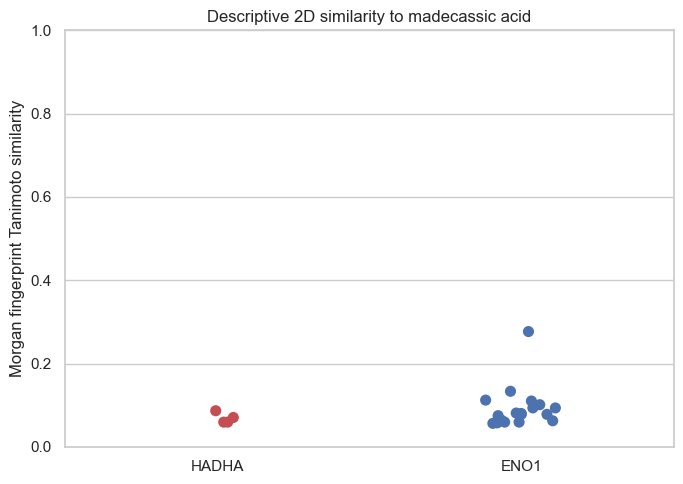

In [19]:
plt.figure(figsize=(7, 5))

sns.stripplot(
    data=similarity_df,
    x="Target",
    y="Tanimoto similarity to madecassic acid",
    order=TARGET_ORDER,
    hue="Target",
    palette={
        "HADHA": "#C44E52",
        "ENO1": "#4C72B0",
    },
    jitter=0.12,
    size=8,
    legend=False
)

plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Morgan fingerprint Tanimoto similarity")
plt.title("Descriptive 2D similarity to madecassic acid")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "madecassic_acid_similarity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation and next step

Overall, the similarity analysis suggests only limited two-dimensional structural similarity and does not indicate a common binding mode. The higher maximum similarity observed within the ENO1-associated set reflects the composition of this small and heterogeneous public dataset; it cannot be used to support, refute, or rank structure-based hypotheses relating to madecassic acid.

The public HADHA dataset is too limited to support development of a target-specific ligand-based model. This reflects restricted public data availability and assay coverage, rather than providing evidence against binding of madecassic acid, or a related analogue, to HADHA.

Although more unique structures were identified for ENO1 than for HADHA, the ENO1 dataset is also unsuitable for modelling in its current form. The records differ in endpoint type, assay conditions, measurement definitions, relation operators, units, source documents, and experimental context. Consequently, differences in descriptor distributions or two-dimensional similarity should not be interpreted as differences in potency, target preference, selectivity, ligandability, or therapeutic relevance.

The available data therefore cannot support a quantitative ENO1 potency model, a binary activity classifier, or a comparative model of HADHA versus ENO1 target preference. Rather than attempting to force a model from unsuitable data, the next stage should assess the structure-based hypothesis using complementary approaches. These should include selection of an appropriate receptor state, evaluation of the proposed binding pocket, docking quality control using suitable positive and negative controls, analogue prioritisation, and direct biochemical or biophysical testing.

As the public ligand data cannot establish relative preference for HADHA over ENO1, the next phase should specify in advance the receptor state, negative controls, and biochemical readouts needed to test the hypothesis robustly.

## Proposed orthogonal validation plan

This audit does not determine the receptor state, docking procedure, or experimental assay to be used. These should be defined in advance of any further structure-based or experimental work.

1. Receptor state: For both HADHA and ENO1, specify the protein construct, biological assembly, cofactors, bound ligands, protonation states, and structural source before undertaking docking or binding-pocket comparisons.

2. Controls: Where possible, include a positive control with independently supported activity, alongside chemically related inactive or lower-priority analogues and appropriate procedural negative controls. These controls should be chosen before the docking results are reviewed.

3. Readouts: Direct biochemical or biophysical assays should be prioritised where feasible, as these can distinguish target engagement from downstream effects observed in cellular systems. The assay format, concentration range, replication strategy, acceptance criteria, and rules for interpreting the results should be specified before testing begins.

4. Decision rule: A structural prediction should only be considered supported if it is reproducible using the pre-defined computational controls and agrees with findings from an independent experimental method.

In [20]:
provenance.to_csv(
    OUTPUT_DIR / "data_provenance.csv",
    index=False
)

curation_audit.to_csv(
    OUTPUT_DIR / "curation_audit.csv",
    index=False
)

duplicate_provenance.to_csv(
    OUTPUT_DIR / "duplicate_provenance.csv",
    index=False
)

multicomponent_audit.to_csv(
    OUTPUT_DIR / "multicomponent_audit.csv",
    index=False
)

structure_audit.to_csv(
    OUTPUT_DIR / "structure_audit.csv",
    index=False
)

similarity_df.to_csv(
    OUTPUT_DIR / "madecassic_acid_similarity.csv",
    index=False
)

madecassic_acid_summary.to_csv(
    OUTPUT_DIR / "madecassic_acid_reference.csv",
    index=False
)

## References

1. Sansom, G. N.; Friar, E. P.; Shorthouse, D.; Tran, T. T. P.; Sialana, F.; Do, T. T.; Van Tran, C.; Be, Y. T. H.; Van Tran, S.; Garrett, M. D.; Serpell, C. J. Identification of Molecular Pathways Involved in the Anti-Liver Cancer Activity of Madecassic Acid. *bioRxiv* 2025. https://doi.org/10.1101/2025.08.17.670739

2. Mendez, D.; Gaulton, A.; Bento, A. P.; et al. ChEMBL: Towards Direct Deposition of Bioassay Data. *Nucleic Acids Research* **2019**, *47*, D930–D940. https://doi.org/10.1093/nar/gky1075

3. Landrum, G. RDKit: Open-Source Cheminformatics. https://www.rdkit.org/ (accessed 2026-07-13).

4. Rogers, D.; Hahn, M. Extended-Connectivity Fingerprints. *Journal of Chemical Information and Modeling* **2010**, *50*, 742–754. https://doi.org/10.1021/ci100050t

5. Bemis, G. W.; Murcko, M. A. The Properties of Known Drugs. 1. Molecular Frameworks. *Journal of Medicinal Chemistry* **1996**, *39*, 2887–2893. https://doi.org/10.1021/jm9602928

6. National Center for Biotechnology Information. PubChem Compound Summary for CID 73412, Madecassic Acid. https://pubchem.ncbi.nlm.nih.gov/compound/73412 (accessed 2026-07-13).